In [6]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [8]:
train_df = pd.read_csv("fashion-mnist_train.csv")
test_df = pd.read_csv("fashion-mnist_test.csv")

In [10]:
X_train = train_df.drop("label", axis=1).values
y_train = train_df["label"].values

X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [38]:
'''model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])'''
model = keras.Sequential([
    layers.Reshape((28,28,1), input_shape=(784,)),
    
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

C:\Users\sai\anaconda3\Lib\site-packages\keras\src\layers\reshaping\reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [40]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ reshape (Reshape)                    │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
history = model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.7949 - loss: 0.5743 - val_accuracy: 0.8558 - val_loss: 0.4075
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.8701 - loss: 0.3646 - val_accuracy: 0.8803 - val_loss: 0.3399
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.8835 - loss: 0.3214 - val_accuracy: 0.8877 - val_loss: 0.3152
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.8918 - loss: 0.2949 - val_accuracy: 0.8897 - val_loss: 0.3008
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.9035 - loss: 0.2661 - val_accuracy: 0.8954 - val_loss: 0.2892
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.9088 - loss: 0.2468 - val_accuracy: 0.9054 - val_loss: 0.2662
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.9153 - loss: 0.2287 - val_accuracy: 0.9014 - val_loss: 0.2777
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.9223 - loss: 0.2119 - 

In [44]:
loss, accuracy = model.evaluate(X_test, y_test_cat)

print("\nTest Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9156 - loss: 0.2311

Test Accuracy: 0.9156000018119812


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


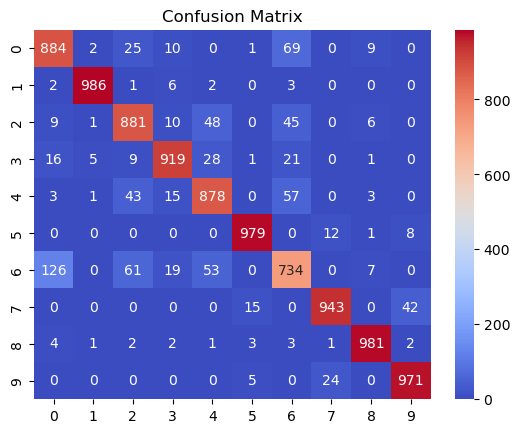

In [46]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap="coolwarm")
plt.title("Confusion Matrix")
plt.show()

In [48]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test   # already numeric

print("\nSample Predictions:")
for i in range(20):
    print("Actual:", class_names[y_true[i]],
          "| Predicted:", class_names[y_pred_classes[i]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Sample Predictions:
Actual: T-shirt/top | Predicted: T-shirt/top
Actual: Trouser | Predicted: Trouser
Actual: Pullover | Predicted: Pullover
Actual: Pullover | Predicted: Pullover
Actual: Dress | Predicted: Dress
Actual: Pullover | Predicted: Shirt
Actual: Bag | Predicted: Bag
Actual: Shirt | Predicted: Shirt
Actual: Sandal | Predicted: Sandal
Actual: T-shirt/top | Predicted: T-shirt/top
Actual: Dress | Predicted: Dress
Actual: Coat | Predicted: Pullover
Actual: Coat | Predicted: Coat
Actual: Shirt | Predicted: Shirt
Actual: Bag | Predicted: Bag
Actual: Sandal | Predicted: Sandal
Actual: Shirt | Predicted: Shirt
Actual: Dress | Predicted: Dress
Actual: Shirt | Predicted: Shirt
Actual: Coat | Predicted: Coat


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


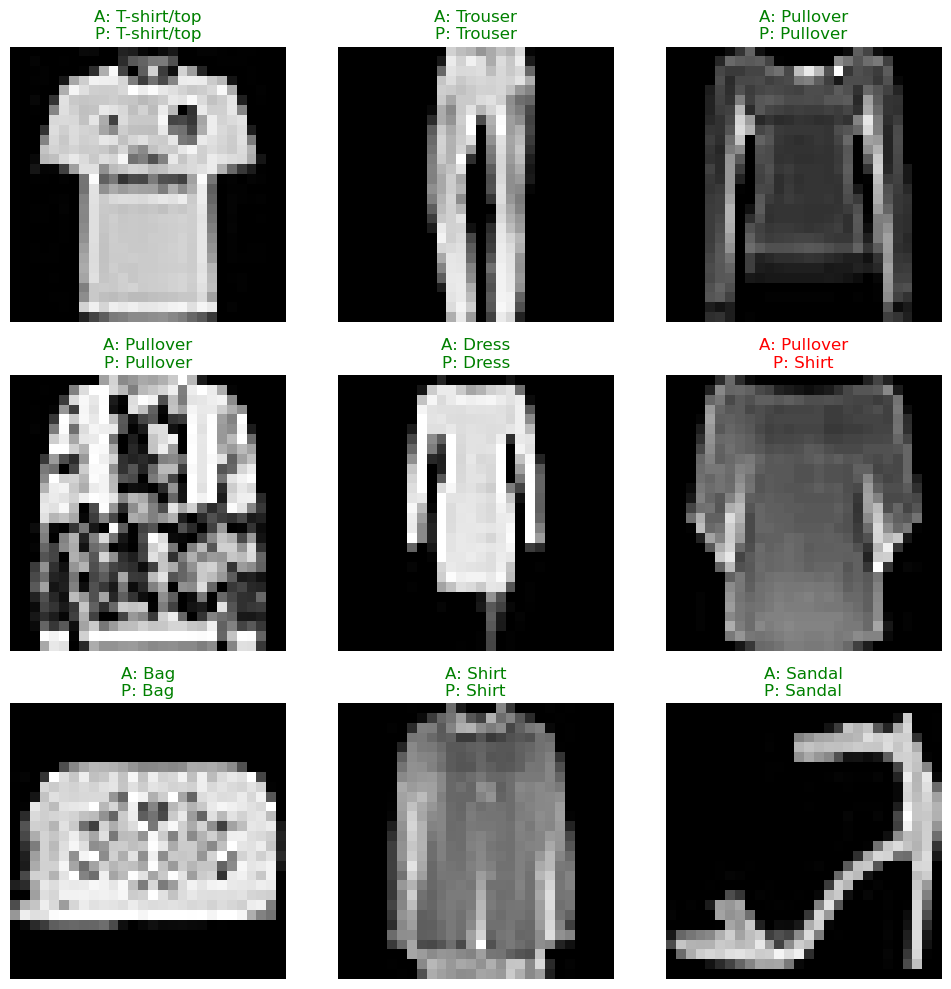

In [50]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

plt.figure(figsize=(10,10))

for i in range(9):   # show 9 images
    plt.subplot(3,3,i+1)
    
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    
    actual = class_names[y_test[i]]
    pred = class_names[y_pred_classes[i]]
    
    if y_test[i] == y_pred_classes[i]:
        color = "green"   # correct
    else:
        color = "red"     # wrong
    
    plt.title(f"A: {actual}\nP: {pred}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()